In [6]:
!pip -q install --no-deps timm==0.9.2 segmentation-models-pytorch==0.3.3 albumentations==1.4.6

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.5/68.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 39.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.7/106.7 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.5/153.5 kB 12.8 MB/s eta 0:00:00


In [7]:
!pip -q install "numpy<2.1" "scipy<1.14" "opencv-python-headless==4.9.0.80" "torch" "torchvision"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 38.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 50.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 52.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 49.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 3.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 16.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━

In [8]:
!pip install timm albumentations segmentation-models-pytorch pretrainedmodels

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 87.7 MB/s eta 0:00:00:00:0100:01
  Created wheel for pretrainedmodels: filename=pretrainedmodels-0.7.4-py3-none-any.whl size=60945 sha256=c0caabda5929d74ee5ac86b2293717616cc18c8a902dc2d1bf79d3e1e31eb3ea
  Stored in directory: /root/.cache/pip/wheels/5f/5b/96/fd94bc35962d7c6b699e8814db545155ac91d2b95785e1b035
  Created wheel for efficientnet-pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16426 sha256=76fe3821226ea19655c53eb4739bb476ff814c521ead16e3e219dab687243c6d
  Stored in directory: /root/.cache/pip/wheels/8b/6f/9b/231a832f811ab6ebb1b32455b177ffc6b8b1cd8de19de70c09
Successfully built pretrainedmodels efficientnet-pytorch
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
     

In [9]:
import os
import gc
import sys
import math
import random
import warnings
from pathlib import Path
from tqdm import tqdm

import numpy as np
import pandas as pd
import cv2
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F 
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

import albumentations as A
from albumentations.pytorch import ToTensorV2

import timm  # For EfficientNet backbone
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [5]:
print("numpy", np.__version__)
print("torch", torch.__version__)
print("timm", timm.__version__)
print("smp", smp.__version__)
print("cv2", cv2.__version__)

numpy 1.26.4
torch 2.6.0+cu124
timm 0.9.2
smp 0.3.3
cv2 4.9.0


In [10]:
warnings.filterwarnings("ignore")

In [11]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

In [12]:
DATA_DIR = "/kaggle/input/severstal-steel-defect-detection"
TRAIN_IMG_DIR = os.path.join(DATA_DIR, "train_images")
TEST_IMG_DIR  = os.path.join(DATA_DIR, "test_images")
TRAIN_CSV     = os.path.join(DATA_DIR, "train.csv")
SAMPLE_SUB    = os.path.join(DATA_DIR, "sample_submission.csv")

In [13]:
HEIGHT, WIDTH = 256, 1600
IMG_EXTS = (".jpg", ".jpeg", ".png")    
BATCH_SIZE = 4
ACCUM_STEPS = 1
NUM_WORKERS = 2
EPOCHS = 10
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

In [14]:
ENCODER = "timm-efficientnet-b0" 
ENCODER_WEIGHTS = "noisy-student"  
ACTIVATION = None          

In [16]:
def rle_encode(mask):
    """
    mask: 2D binary array, 1 - mask, 0 - background. 
    Returns run-length as string per Kaggle spec: spaced pairs "start length".
    """
    pixels = mask.T.flatten()  # (W*H,) — note transpose to match competition orientation
    pixels = np.concatenate([[0], pixels, [0]])
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] = runs[1::2] - runs[::2]
    return " ".join(str(x) for x in runs)

In [17]:
def rle_decode(rle, shape=(HEIGHT, WIDTH)):
    """
    rle: "start length" pairs string; returns 2D binary mask (H,W)
    """
    mask = np.zeros(shape[0]*shape[1], dtype=np.uint8)
    if not isinstance(rle, str) or rle.strip() == "":
        return mask.reshape(shape, order="F")  # clearer

    s = list(map(int, rle.split()))
    starts, lengths = s[0::2], s[1::2]
    starts = np.asarray(starts) - 1
    ends   = starts + np.asarray(lengths)
    for lo, hi in zip(starts, ends):
        mask[lo:hi] = 1
    return mask.reshape(shape, order="F")

In [18]:
df = pd.read_csv(TRAIN_CSV)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7095 entries, 0 to 7094
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   ImageId        7095 non-null   object
 1   ClassId        7095 non-null   int64 
 2   EncodedPixels  7095 non-null   object
dtypes: int64(1), object(2)
memory usage: 166.4+ KB


In [15]:
df.head()

,ImageId,ClassId,EncodedPixels
0,0002cc93b.jpg,1,29102 12 29346 24 29602 24 29858 24 30114 24 3...
1,0007a71bf.jpg,3,18661 28 18863 82 19091 110 19347 110 19603 11...
2,000a4bcdd.jpg,1,37607 3 37858 8 38108 14 38359 20 38610 25 388...
3,000f6bf48.jpg,4,131973 1 132228 4 132483 6 132738 8 132993 11 ...
4,0014fce06.jpg,3,229501 11 229741 33 229981 55 230221 77 230468...


In [16]:
df["ClassId"].unique()

array([1, 3, 4, 2])

In [17]:
df = df[["ImageId","ClassId","EncodedPixels"]].sort_values(["ImageId","ClassId"]).reset_index(drop=True)
print(df.head())

         ImageId  ClassId                                      EncodedPixels
0  0002cc93b.jpg        1  29102 12 29346 24 29602 24 29858 24 30114 24 3...
1  0007a71bf.jpg        3  18661 28 18863 82 19091 110 19347 110 19603 11...
2  000a4bcdd.jpg        1  37607 3 37858 8 38108 14 38359 20 38610 25 388...
3  000f6bf48.jpg        4  131973 1 132228 4 132483 6 132738 8 132993 11 ...
4  0014fce06.jpg        3  229501 11 229741 33 229981 55 230221 77 230468...


In [19]:
records = {}
for img, g in df.groupby("ImageId"):
    rec = {1: np.nan, 2: np.nan, 3: np.nan, 4: np.nan}
    for _, row in g.iterrows():
        rec[int(row.ClassId)] = row.EncodedPixels if isinstance(row.EncodedPixels, str) else np.nan
    records[img] = rec

In [20]:
all_train_ids_disk = sorted([f for f in os.listdir(TRAIN_IMG_DIR) if f.lower().endswith(IMG_EXTS)])
for img_id in all_train_ids_disk:
    records.setdefault(img_id, {1: np.nan, 2: np.nan, 3: np.nan, 4: np.nan})

In [21]:
records = {k: v for k, v in records.items() if k in all_train_ids_disk}

In [21]:
print("Total train images considered:", len(records))

Total train images considered: 12568


In [22]:
all_image_ids = sorted(records.keys())
labels = np.array([
    1 if any(isinstance(r, str) and r.strip() != "" for r in records[i].values()) else 0
    for i in all_image_ids
])

In [23]:
train_ids, valid_ids = train_test_split(
    all_image_ids,
    test_size=0.1,
    stratify=labels,
    random_state=SEED
)

In [24]:
def ratio(ids):
    arr = np.array([1 if any(isinstance(r, str) and r.strip() != "" for r in records[i].values()) else 0
                    for i in ids])
    return arr.mean()

In [25]:
print(f"Train: {len(train_ids)}, Valid: {len(valid_ids)}")
print(f"Defect ratio overall: {labels.mean():.3f}")
print(f"Defect ratio train:   {ratio(train_ids):.3f}")
print(f"Defect ratio valid:   {ratio(valid_ids):.3f}")

Train: 11311, Valid: 1257
Defect ratio overall: 0.530
Defect ratio train:   0.530
Defect ratio valid:   0.531


In [25]:
def build_transforms(train=True):
    # Always ensure (H,W) == (HEIGHT, WIDTH) BEFORE normalization/tensor
    if train:
        return A.Compose([
            A.Resize(HEIGHT, WIDTH),
            A.HorizontalFlip(p=0.5),
            A.ShiftScaleRotate(
                shift_limit=0.05, scale_limit=0.05, rotate_limit=5,
                border_mode=cv2.BORDER_REFLECT_101, p=0.5
            ),
            A.RandomBrightnessContrast(p=0.5),
            A.GaussianBlur(blur_limit=(3, 5), p=0.2),
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2()
        ])
    else:
        return A.Compose([
            A.Resize(HEIGHT, WIDTH),
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2()
        ])


class SeverstalDataset(Dataset):
    def __init__(self, image_ids, records, img_dir, transforms=None):
        self.image_ids = image_ids
        self.records = records
        self.img_dir = img_dir
        self.transforms = transforms

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_path = os.path.join(self.img_dir, img_id)

        # read BGR -> RGB
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        if img is None:
            raise FileNotFoundError(f"Could not read image: {img_path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Build 4-channel mask (H,W,4) at TARGET size
        mask = np.zeros((HEIGHT, WIDTH, 4), dtype=np.uint8)
        for c in (1, 2, 3, 4):
            rle = self.records.get(img_id, {}).get(c, np.nan)
            mask[..., c - 1] = rle_decode(rle, shape=(HEIGHT, WIDTH))

        if self.transforms:
            aug = self.transforms(image=img, mask=mask)
            img  = aug["image"]                          # torch.float32, (3,H,W)

            # Albumentations may return mask as HWC; make it CHW explicitly
            m = aug["mask"]
            if isinstance(m, torch.Tensor):
                # If (H,W,4) -> (4,H,W)
                if m.ndim == 3:
                    m = m.permute(2, 0, 1)
            else:
                # numpy -> tensor, then permute
                m = torch.from_numpy(m).permute(2, 0, 1)
            mask = m.float()                              # torch.float32, (4,H,W)
        else:
            # Fallback: manually resize & convert
            img  = cv2.resize(img, (WIDTH, HEIGHT))
            img  = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
            mask = torch.from_numpy(mask).permute(2, 0, 1).float()

        return img, mask, img_id

In [26]:
train_ds = SeverstalDataset(train_ids, records, TRAIN_IMG_DIR, build_transforms(True))
valid_ds = SeverstalDataset(valid_ids, records, TRAIN_IMG_DIR, build_transforms(False))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

In [28]:
len(train_loader), len(valid_loader)

(2827, 315)

In [27]:
try:
    model = smp.Unet(encoder_name=ENCODER, encoder_weights=ENCODER_WEIGHTS, in_channels=3, classes=4, activation=ACTIVATION)
except Exception as e:
    print(f"Failed to load encoder weights ({ENCODER_WEIGHTS}): {e}\nFalling back to random init.")
    model = smp.Unet(encoder_name=ENCODER, encoder_weights=None, in_channels=3, classes=4, activation=ACTIVATION)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-weights/tf_efficientnet_b0_ns-c0e6a31c.pth" to /root/.cache/torch/hub/checkpoints/tf_efficientnet_b0_ns-c0e6a31c.pth
100%|██████████| 20.4M/20.4M [00:00<00:00, 98.2MB/s]


Unet(
  (encoder): EfficientNetEncoder(
    (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): Swish()
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn1): BatchNormAct2d(
            32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): Swish()
          )
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (act1): Swish()
            (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (gate): Sigmoid()
          )
          (conv_pw): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [28]:
# Loss: BCEWithLogits + soft dice
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
    def forward(self, logits, targets):
        # sigmoid inside dice for stability
        probs = torch.sigmoid(logits)
        targets = targets.float()
        dims = (0,2,3)
        intersection = torch.sum(probs*targets, dims)
        union = torch.sum(probs, dims) + torch.sum(targets, dims)
        dice = (2.*intersection + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()

bce = nn.BCEWithLogitsLoss()
dice = DiceLoss()

In [29]:
def criterion(logits, targets, alpha=0.5):
    return alpha * bce(logits, targets) + (1-alpha) * dice(logits, targets)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

In [30]:
def dice_coef_from_logits(logits, targets, eps=1.0, thr=0.5):
    """
    logits: torch.Tensor (B,4,H,W)
    targets: torch.Tensor (B,4,H,W) in {0,1}
    Returns mean Dice over batch & classes, using hard threshold.
    """
    probs = torch.sigmoid(logits)
    preds = (probs > thr).float()
    dims = (0, 2, 3)
    inter = (preds * targets).sum(dim=dims)
    union = preds.sum(dim=dims) + targets.sum(dim=dims)
    dice = (2 * inter + eps) / (union + eps)
    return dice.mean()

In [31]:
def run_epoch(loader, train=True):
    model.train(train)
    epoch_loss, epoch_dice = 0.0, 0.0
    n_samples = 0

    pbar = tqdm(loader, leave=False)
    if train:
        optimizer.zero_grad(set_to_none=True)

    for step, (imgs, masks, _) in enumerate(pbar):
        imgs  = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits = model(imgs)
            loss   = criterion(logits, masks)
            dice_m = dice_coef_from_logits(logits, masks)

        if train:
            scaler.scale(loss / ACCUM_STEPS).backward()
            if (step + 1) % ACCUM_STEPS == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)

        bs = imgs.size(0)
        epoch_loss += loss.item() * bs
        epoch_dice += dice_m.item() * bs
        n_samples  += bs
        pbar.set_postfix(loss=f"{loss.item():.4f}", dice=f"{dice_m.item():.4f}")

    return epoch_loss / n_samples, epoch_dice / n_samples

In [32]:
x, y, _ = train_ds[0]
print("img", tuple(x.shape), "mask", tuple(y.shape))

img (3, 256, 1600) mask (4, 256, 1600)


In [35]:
best_val_dice = -1.0
for epoch in range(1, EPOCHS + 1):
    train_loss, train_dice = run_epoch(train_loader, train=True)
    val_loss,   val_dice   = run_epoch(valid_loader, train=False)
    scheduler.step()

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"train: loss={train_loss:.4f} dice={train_dice:.4f} | "
          f"valid: loss={val_loss:.4f} dice={val_dice:.4f} | "
          f"lr={scheduler.get_last_lr()[0]:.2e}")

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), "best_unet_efficientnet.pth")
        print(f"  ↳ Saved new best (val Dice={best_val_dice:.4f}).")

Epoch 01/10 | train: loss=0.4561 dice=0.5285 | valid: loss=0.4372 dice=0.5552 | lr=2.93e-04
  ↳ Saved new best (val Dice=0.5552).


Epoch 02/10 | train: loss=0.2192 dice=0.6586 | valid: loss=0.1569 dice=0.7538 | lr=2.71e-04
  ↳ Saved new best (val Dice=0.7538).


Epoch 03/10 | train: loss=0.1487 dice=0.7537 | valid: loss=0.1566 dice=0.7618 | lr=2.38e-04
  ↳ Saved new best (val Dice=0.7618).


Epoch 04/10 | train: loss=0.1460 dice=0.7558 | valid: loss=0.1490 dice=0.7681 | lr=1.96e-04
  ↳ Saved new best (val Dice=0.7681).


Epoch 05/10 | train: loss=0.1413 dice=0.7608 | valid: loss=0.1474 dice=0.7658 | lr=1.50e-04


Epoch 06/10 | train: loss=0.1295 dice=0.7796 | valid: loss=0.1224 dice=0.8022 | lr=1.04e-04
  ↳ Saved new best (val Dice=0.8022).


Epoch 07/10 | train: loss=0.1206 dice=0.7923 | valid: loss=0.1415 dice=0.7780 | lr=6.18e-05


Epoch 08/10 | train: loss=0.1163 dice=0.8006 | valid: loss=0.1218 dice=0.8106 | lr=2.86e-05
  ↳ Saved new best (val Dice=0.8106).


Epoch 09/10 | train: loss=0.1150 dice=0.8019 | valid: loss=0.1198 dice=0.8093 | lr=7.34e-06


Epoch 10/10 | train: loss=0.1126 dice=0.8073 | valid: loss=0.1212 dice=0.8096 | lr=0.00e+00


In [33]:
def sigmoid(x): return 1/(1+np.exp(-x))

def remove_small_regions(mask, min_area=1000):
    """Keep only connected components larger than min_area (per class)."""
    # mask: (H,W) binary uint8
    nb_components, output, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    sizes = stats[1:, -1]; nb_components -= 1
    cleaned = np.zeros_like(mask)
    for i in range(nb_components):
        if sizes[i] >= min_area:
            cleaned[output == i+1] = 1
    return cleaned

@torch.no_grad()
def predict_batch(imgs, tta=False):
    model.eval()
    imgs = imgs.to(device)
    logits = model(imgs)  # (B,4,H,W)
    if tta:
        # Simple TTA: horizontal flip
        imgs_fl = torch.flip(imgs, dims=[3])
        logits_fl = model(imgs_fl)
        logits = (logits + torch.flip(logits_fl, dims=[3])) / 2.0
    return logits.sigmoid().cpu().numpy()

def masks_to_rles(prob_maps, threshold=0.5, min_area=0):
    """
    prob_maps: (4,H,W) float in [0,1]
    returns list of 4 RLE strings (NaN if empty)
    """
    rles = []
    for c in range(4):
        m = (prob_maps[c] > threshold).astype(np.uint8)
        if min_area > 0:
            m = remove_small_regions(m, min_area=min_area).astype(np.uint8)
        if m.sum() == 0:
            rles.append(np.nan)
        else:
            rles.append(rle_encode(m))
    return rles

In [37]:
# Load best model weights (if exist)
if os.path.exists("best_unet_efficientnet.pth"):
    model.load_state_dict(torch.load("best_unet_efficientnet.pth", map_location=device))

test_ids = sorted(os.listdir(TEST_IMG_DIR))
test_tfms = build_transforms(train=False)

In [38]:
class TestDataset(Dataset):
    def __init__(self, image_ids, img_dir, transforms):
        self.image_ids = image_ids; self.img_dir = img_dir; self.transforms = transforms
    def __len__(self): return len(self.image_ids)
    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        path = os.path.join(self.img_dir, img_id)
        img = cv2.imread(path, cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        t = self.transforms(image=img)
        return t["image"], img_id

test_ds = TestDataset(test_ids, TEST_IMG_DIR, test_tfms)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

In [39]:
# Inference
all_rows = []
THRESH = 0.5
MIN_AREA = 1000 
USE_TTA = True

for imgs, ids in tqdm(test_loader):
    probs = predict_batch(imgs, tta=USE_TTA)   # (B,4,H,W)
    for p, img_id in zip(probs, ids):
        rles = masks_to_rles(p, threshold=THRESH, min_area=MIN_AREA)
        # 4 rows per image in required order 1..4
        for cls_idx, rle in enumerate(rles, start=1):
            all_rows.append({
                "ImageId_ClassId": f"{img_id}_{cls_idx}",
                "EncodedPixels": rle if isinstance(rle, str) else ""
            })

sub = pd.DataFrame(all_rows, columns=["ImageId_ClassId", "EncodedPixels"])
sub.to_csv("submission.csv", index=False)
sub.head(8)

100%|██████████| 1377/1377 [03:23<00:00,  6.76it/s]


,ImageId_ClassId,EncodedPixels
0,0000f269f.jpg_1,
1,0000f269f.jpg_2,
2,0000f269f.jpg_3,146163 9 146179 9 146258 7 146327 27 146360 10...
3,0000f269f.jpg_4,
4,000ccc2ac.jpg_1,
5,000ccc2ac.jpg_2,
6,000ccc2ac.jpg_3,
7,000ccc2ac.jpg_4,


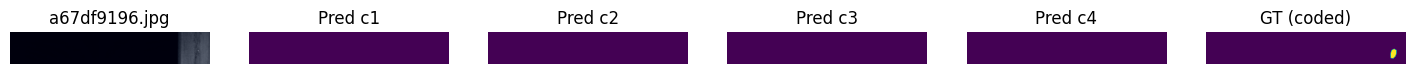

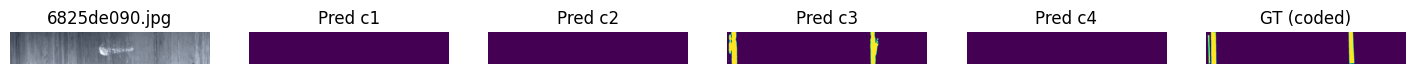

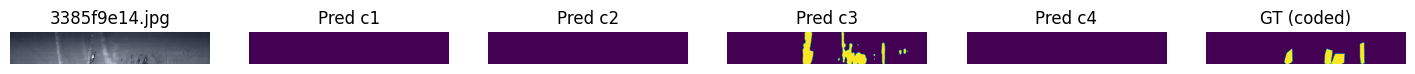

In [40]:
model.eval()
samples = 3
for i in range(samples):
    img, mask, img_id = valid_ds[i]
    with torch.no_grad():
        pr = predict_batch(img.unsqueeze(0), tta=True)[0]  # (4,H,W)
    fig, axes = plt.subplots(1, 6, figsize=(18,5))
    axes[0].imshow(img.permute(1,2,0).cpu().numpy()*0.25 + 0.5) ; axes[0].set_title(img_id) ; axes[0].axis('off')
    for c in range(4):
        axes[c+1].imshow(pr[c] > 0.5) ; axes[c+1].set_title(f"Pred c{c+1}") ; axes[c+1].axis('off')
    axes[5].imshow(mask[0] + 2*mask[1] + 3*mask[2] + 4*mask[3]) ; axes[5].set_title("GT (coded)") ; axes[5].axis('off')
    plt.show()

In [34]:
def denorm(img_t):
    x = img_t.permute(1,2,0).cpu().numpy()
    x = x * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    return np.clip(x, 0, 1)

@torch.no_grad()
def show_val_samples(model, valid_ds, device, k=3, thr=0.5):
    model.eval()
    idxs = np.random.choice(len(valid_ds), size=min(k, len(valid_ds)), replace=False)
    for i in idxs:
        img, mask, img_id = valid_ds[i]                    # <— uses img_id (str)
        x  = img.unsqueeze(0).to(device)
        p1 = model(x).sigmoid()
        p2 = model(torch.flip(x, dims=[3])).sigmoid()
        probs = ((p1 + torch.flip(p2, dims=[3]))/2)[0].cpu().numpy()
        pr = (probs > thr).astype(np.uint8)

        fig, axes = plt.subplots(1, 9, figsize=(20,4))
        axes[0].imshow(denorm(img)); axes[0].set_title(img_id); axes[0].axis('off')
        for c in range(4):
            axes[1+c].imshow(mask[c].cpu(), cmap='gray');  axes[1+c].set_title(f"GT c{c+1}");   axes[1+c].axis('off')
        for c in range(4):
            axes[5+c].imshow(pr[c], cmap='gray');          axes[5+c].set_title(f"Pred c{c+1}"); axes[5+c].axis('off')
        plt.tight_layout(); plt.show()

def plot_training_curves(history, out_dir="/kaggle/working", show=True):
    tr_d = [e["dice"] for e in history["train"]]
    va_d = [e["dice"] for e in history["valid"]]
    tr_l = [e["loss"] for e in history["train"]]
    va_l = [e["loss"] for e in history["valid"]]
    lr   = [e["lr"]  for e in history["train"]]

    plt.figure(figsize=(6,4)); plt.plot(tr_d,label="Train Dice"); plt.plot(va_d,label="Valid Dice")
    plt.title("Dice Score"); plt.xlabel("Epoch"); plt.ylabel("Dice"); plt.legend(); plt.grid(True)
    if show: plt.show(); plt.close()

    plt.figure(figsize=(6,4)); plt.plot(tr_l,label="Train Loss"); plt.plot(va_l,label="Valid Loss")
    plt.title("Loss"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True)
    if show: plt.show(); plt.close()

    plt.figure(figsize=(6,4)); plt.plot(lr,label="LR")
    plt.title("Learning Rate"); plt.xlabel("Epoch"); plt.ylabel("LR"); plt.grid(True)
    if show: plt.show(); plt.close()

@torch.no_grad()
def plot_per_class_dice(model, loader, device, class_names=None):
    """
    Requires a dice_per_class(logits, targets) -> np.array/list of 4 dice scores.
    """
    model.eval()
    out = []
    for imgs, masks, _ in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        logits = model(imgs)
        out.append(dice_per_class(logits, masks))
    dices = np.array(out).mean(0)
    if class_names is None:
        class_names = [f"Class {i+1}" for i in range(len(dices))]
    plt.figure(figsize=(6,4))
    plt.bar(class_names, dices)
    plt.title("Per-Class Dice Scores"); plt.ylabel("Dice"); plt.ylim(0,1); plt.grid(True, axis="y")
    plt.show()

In [ ]:
@torch.no_grad()
def visualize_samples(model, dataset, device, k=3, thr=0.5):
    model.eval()
    idxs = np.random.choice(len(dataset), size=min(k, len(dataset)), replace=False)
    for i in idxs:
        img, mask, img_id = dataset[i]                     # <— use img_id
        x = img.unsqueeze(0).to(device)
        pred = torch.sigmoid(model(x))[0].cpu().numpy().transpose(1,2,0)  # HWC
        pred_bin = (pred > thr).astype(np.uint8)

        img_np  = img.permute(1,2,0).cpu().numpy()
        mask_np = mask.permute(1,2,0).cpu().numpy()

        fig, axs = plt.subplots(1, 3, figsize=(15,5))
        disp = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)
        axs[0].imshow(disp);               axs[0].set_title(img_id);                  axs[0].axis("off")
        axs[1].imshow(mask_np.max(-1), cmap="gray"); axs[1].set_title("GT (Any)");    axs[1].axis("off")
        axs[2].imshow(pred_bin.max(-1), cmap="gray"); axs[2].set_title("Pred (Any)"); axs[2].axis("off")
        plt.show()

In [43]:
def dice_per_class(logits, targets, eps=1.0, thr=0.5):
    probs = torch.sigmoid(logits)
    preds = (probs > thr).float()
    dims = (0, 2, 3)
    inter = (preds * targets).sum(dim=dims)
    union = preds.sum(dim=dims) + targets.sum(dim=dims)
    dice = (2*inter + eps) / (union + eps)           # shape: (C,)
    return dice.detach().cpu().numpy()

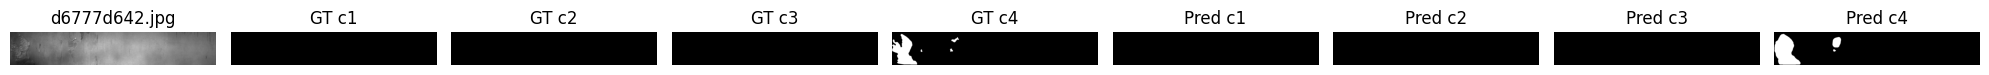

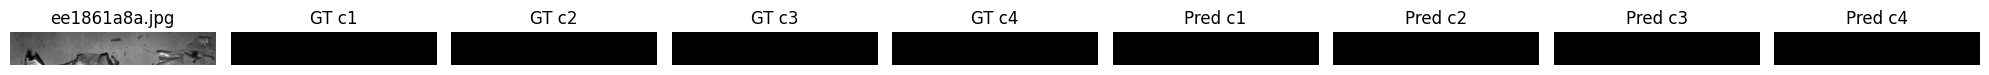

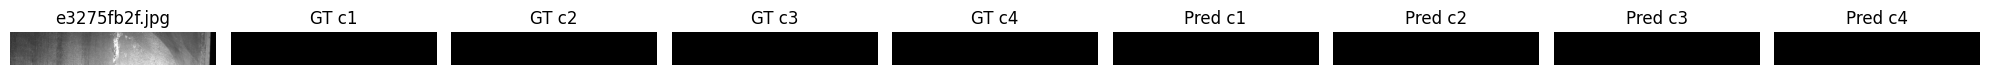

In [44]:
show_val_samples(model, valid_ds, device, k=3, thr=0.5)

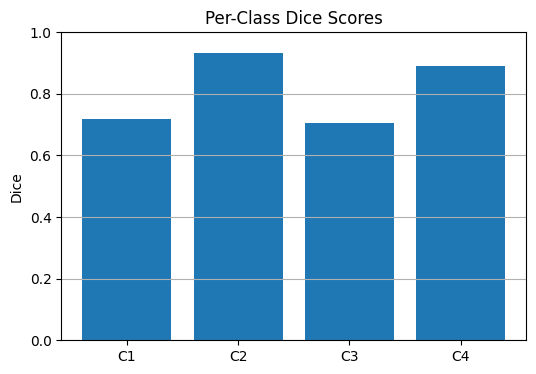

In [45]:
plot_per_class_dice(model, valid_loader, device, class_names=["C1","C2","C3","C4"])

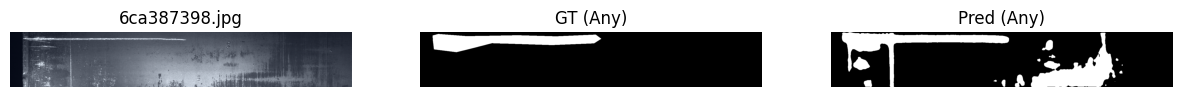

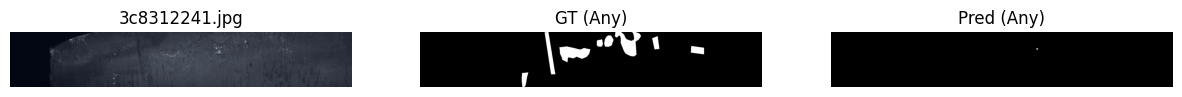

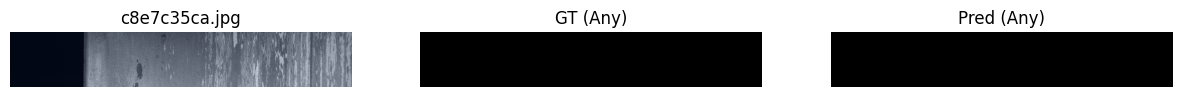

In [46]:
visualize_samples(model, valid_ds, device, k=3, thr=0.5)

In [47]:
# 1) Reload best weights
model.load_state_dict(torch.load("/kaggle/working/best_unet_efficientnet.pth", map_location=device))
model.to(device)
model.eval()

# 2) Metrics used
def dice_per_class(logits, targets, eps=1.0, thr=0.5):
    probs = torch.sigmoid(logits)
    preds = (probs > thr).float()
    dims = (0, 2, 3)
    inter = (preds * targets).sum(dim=dims)
    union = preds.sum(dim=dims) + targets.sum(dim=dims)
    dice = (2*inter + eps) / (union + eps)   # (C,)
    return dice

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss, total_dice, n = 0.0, 0.0, 0
    pcs = []  # per-class dice list
    for imgs, masks, _ in tqdm(loader, leave=False):
        imgs, masks = imgs.to(device), masks.to(device)
        logits = model(imgs)
        loss   = criterion(logits, masks)
        d_mean = dice_coef_from_logits(logits, masks)
        pc     = dice_per_class(logits, masks)  # (4,)

        bs = imgs.size(0)
        total_loss += loss.item() * bs
        total_dice += d_mean.item() * bs
        pcs.append(pc.detach().cpu().numpy())
        n += bs

    pcs = np.stack(pcs).mean(0)
    return total_loss/n, total_dice/n, pcs

val_loss, val_dice, val_pcd = evaluate(model, valid_loader, device)
print(f"Validation -> loss: {val_loss:.4f} | dice: {val_dice:.4f} | per-class: {val_pcd}")

Validation -> loss: 0.1241 | dice: 0.8106 | per-class: [0.7175768  0.9333652  0.70404094 0.8890031 ]


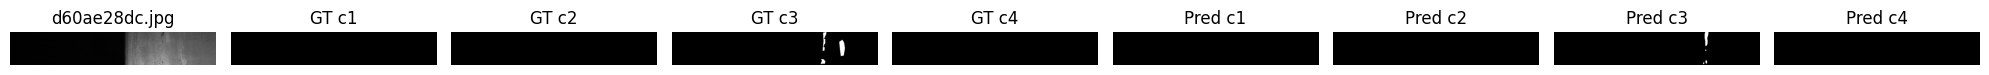

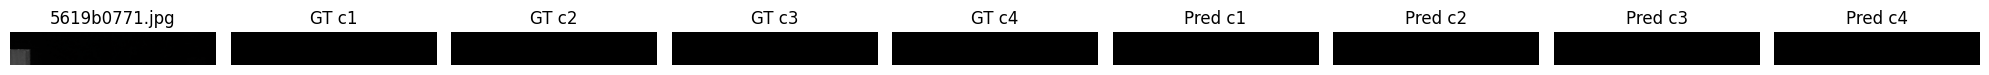

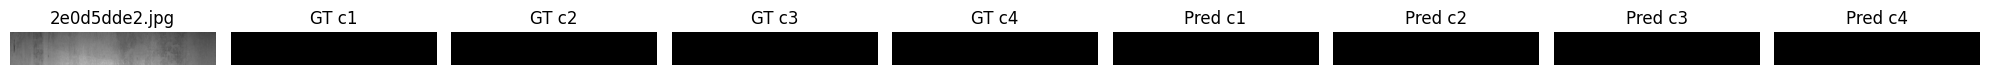

In [48]:
show_val_samples(model, valid_ds, device, k=3, thr=0.5)

In [33]:
import os, json, csv, time, math
from collections import deque

LOG_DIR = "/kaggle/working"
os.makedirs(LOG_DIR, exist_ok=True)
HIST_JSON = os.path.join(LOG_DIR, "history.json")
HIST_CSV  = os.path.join(LOG_DIR, "history.csv")

PATIENCE_EPOCHS     = 10    
MIN_DICE_DELTA      = 1e-3  
MIN_LOSS_DELTA      = 1e-4  
MAX_EPOCHS_SAFETY   = 10000  

history = {"train": [], "valid": []}
if os.path.exists(HIST_JSON):
    try:
        with open(HIST_JSON, "r") as f:
            history = json.load(f)
    except Exception:
        pass

if not os.path.exists(HIST_CSV):
    with open(HIST_CSV, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["epoch","train_loss","train_dice","valid_loss","valid_dice","lr","val_c1","val_c2","val_c3","val_c4","secs"])

val_dice_buf = deque(maxlen=PATIENCE_EPOCHS)
val_loss_buf = deque(maxlen=PATIENCE_EPOCHS)

def is_plateau():
    """Return True if both val_dice ~flat and val_loss ~flat over the window."""
    if len(val_dice_buf) < PATIENCE_EPOCHS:  
        return False
    dice_range = max(val_dice_buf) - min(val_dice_buf)
    loss_range = max(val_loss_buf) - min(val_loss_buf)
    return (dice_range < MIN_DICE_DELTA) and (loss_range < MIN_LOSS_DELTA)

epoch = 0
while epoch < MAX_EPOCHS_SAFETY:
    epoch += 1
    t0 = time.time()

    train_loss, train_dice = run_epoch(train_loader, train=True)
    val_loss,   val_dice   = run_epoch(valid_loader, train=False)

    val_c = None
    try:
        cls_scores = []
        model.eval()
        with torch.no_grad():
            for imgs, masks, _ in valid_loader:
                imgs, masks = imgs.to(device), masks.to(device)
                logits = model(imgs)
                cls_scores.append(dice_per_class(logits, masks))  
        import numpy as np
        val_c = np.array(cls_scores).mean(0).tolist() 
    except Exception:
        val_c = [None, None, None, None]

    try:
        scheduler.step(val_loss)   
    except TypeError:
        scheduler.step()      

    try:
        lr_now = float(scheduler.get_last_lr()[0])
    except Exception:
        lr_now = float(optimizer.param_groups[0]["lr"])

    val_dice_buf.append(float(val_dice))
    val_loss_buf.append(float(val_loss))

    secs = time.time() - t0
    msg = (f"Epoch {epoch:04d} | "
           f"train: loss={train_loss:.4f} dice={train_dice:.4f} | "
           f"valid: loss={val_loss:.4f} dice={val_dice:.4f} | "
           f"lr={lr_now:.2e} | dt={secs:.1f}s")
    print(msg)

    history["train"].append({"loss": float(train_loss), "dice": float(train_dice), "lr": lr_now, "secs": secs})
    history["valid"].append({"loss": float(val_loss),   "dice": float(val_dice)})

    with open(HIST_JSON, "w") as f:
        json.dump(history, f)

    with open(HIST_CSV, "a", newline="") as f:
        w = csv.writer(f)
        w.writerow([epoch, float(train_loss), float(train_dice), float(val_loss), float(val_dice), lr_now,
                    *(val_c if val_c else [None, None, None, None]), secs])

    if is_plateau():
        print(f"Plateau detected over last {PATIENCE_EPOCHS} epochs. Stopping at epoch {epoch}.")
        break

Epoch 0001 | train: loss=0.4559 dice=0.5638 | valid: loss=0.4149 dice=0.6249 | lr=2.99e-04 | dt=725.4s


Epoch 0002 | train: loss=0.2336 dice=0.6690 | valid: loss=0.1616 dice=0.7431 | lr=3.00e-04 | dt=714.0s


Epoch 0003 | train: loss=0.1519 dice=0.7462 | valid: loss=0.1603 dice=0.7401 | lr=3.00e-04 | dt=711.1s


Epoch 0004 | train: loss=0.1466 dice=0.7550 | valid: loss=0.1509 dice=0.7598 | lr=3.00e-04 | dt=712.1s


Epoch 0005 | train: loss=0.1461 dice=0.7565 | valid: loss=0.1541 dice=0.7641 | lr=3.00e-04 | dt=712.0s


...

Epoch 0009 | train: loss=0.1430 dice=0.7602 | valid: loss=0.1529 dice=0.7595 | lr=3.00e-04 | dt=712.5s


Epoch 0010 | train: loss=0.1401 dice=0.7626 | valid: loss=0.1545 dice=0.7649 | lr=3.00e-04 | dt=723.2s


Epoch 0011 | train: loss=0.1386 dice=0.7646 | valid: loss=nan dice=0.7552 | lr=nan | dt=710.1s


Epoch 0012 | train: loss=nan dice=0.6418 | valid: loss=nan dice=0.6379 | lr=nan | dt=697.6s


KeyboardInterrupt: 

In [34]:
def plot_training_curves(history, out_dir="/kaggle/working", show=True):
    """Plots Train/Valid Loss, Dice Score, and Learning Rate from the history dictionary."""
    tr_d = [e["dice"] for e in history["train"]]
    va_d = [e["dice"] for e in history["valid"]]
    tr_l = [e["loss"] for e in history["train"]]
    va_l = [e["loss"] for e in history["valid"]]
    lr   = [e["lr"] for e in history["train"]]

    # Dice Score
    plt.figure(figsize=(6,4))
    plt.plot(tr_d, label="Train Dice")
    plt.plot(va_d, label="Valid Dice")
    plt.title("Dice Score")
    plt.xlabel("Epoch")
    plt.ylabel("Dice")
    plt.legend()
    plt.grid(True)
    # plt.savefig(Path(out_dir)/"dice_curve.png") # Uncomment to save
    if show: plt.show()
    plt.close()

    # Loss Curve
    plt.figure(figsize=(6,4))
    plt.plot(tr_l, label="Train Loss")
    plt.plot(va_l, label="Valid Loss")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    # plt.savefig(Path(out_dir)/"loss_curve.png") # Uncomment to save
    if show: plt.show()
    plt.close()

    # Learning Rate
    plt.figure(figsize=(6,4))
    plt.plot(lr, label="LR")
    plt.title("Learning Rate")
    plt.xlabel("Epoch")
    plt.ylabel("LR")
    plt.grid(True)
    # plt.savefig(Path(out_dir)/"lr_curve.png") # Uncomment to save
    if show: plt.show()
    plt.close()

In [35]:
import json, os
hist = {"train": [], "valid": []}
HIST_PATH = "/kaggle/working/history.json"

In [36]:
print(type(hist))
print(hist.keys() if isinstance(hist, dict) else "not a dict")

print("train len:", len(hist.get("train", [])))
print("valid len:", len(hist.get("valid", [])))

# peek first record
if hist.get("train"):
    print("train[0]:", hist["train"][0])
if hist.get("valid"):
    print("valid[0]:", hist["valid"][0])

<class 'dict'>
dict_keys(['train', 'valid'])
train len: 0
valid len: 0


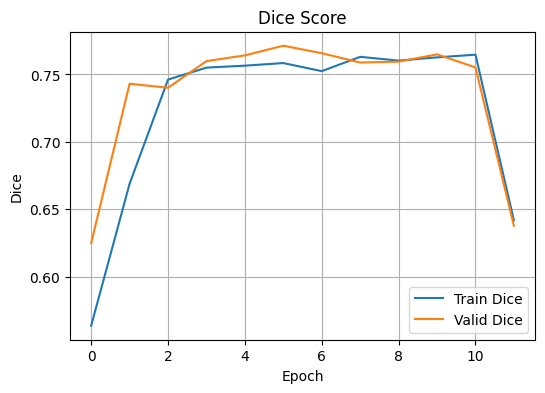

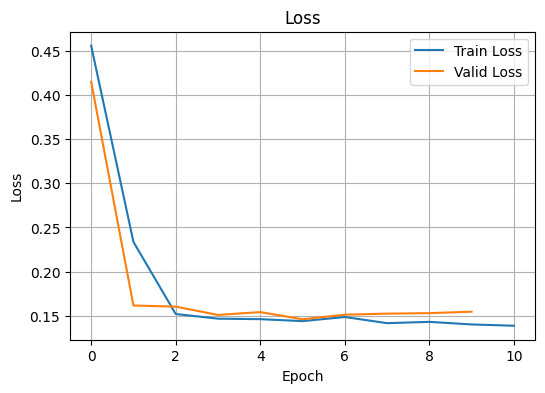

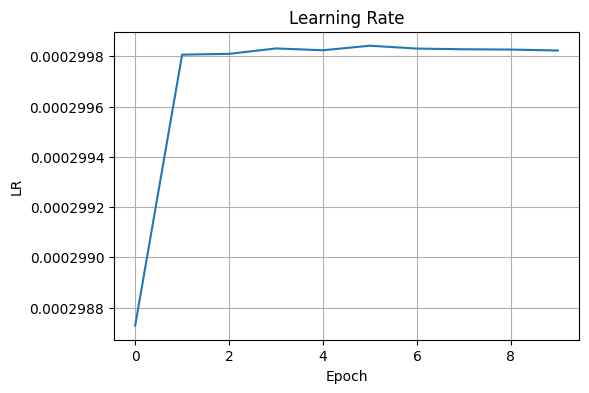

In [37]:
with open("/kaggle/working/history.json", "r") as f:
    hist = json.load(f)

plot_training_curves(hist)